<a href="https://colab.research.google.com/github/alaskaquefalta/CalculoBNotebook/blob/main/C%C3%A1lculoB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recursos da disciplina de Cálculo B

Abaixo, todo o código escrito para a disciplina de Cálculo B, ministrada pela Profª Marline Ilha da Silva, com a colaboração do monitor Alaska. Todo conteúdo abaixo é de autoria própria, com pouca ou nenhuma alteração gerada por Inteligência Artificial.

## Aula 1 - 13/08/2026 — Sequências

### Gráfico demonstrando convergência de uma sequência

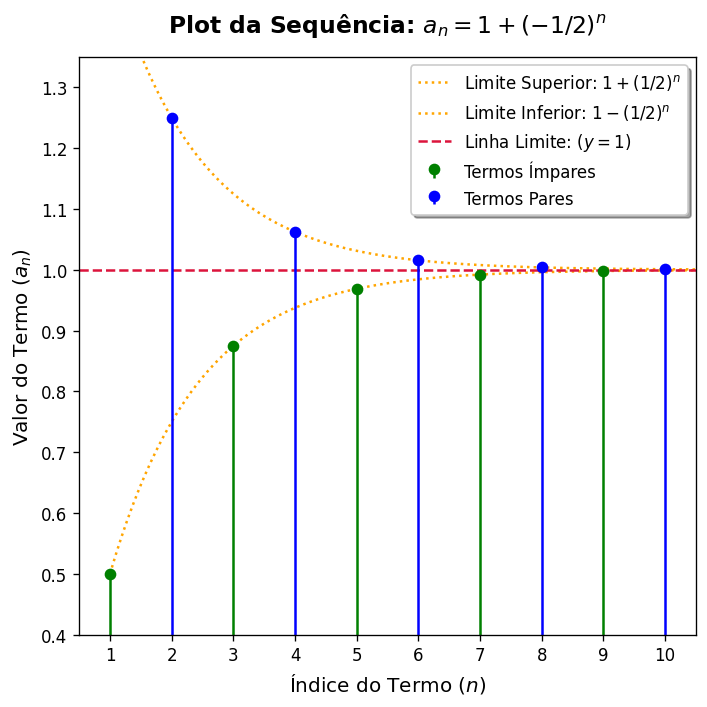

In [17]:
# %%

import numpy as np
import matplotlib.pyplot as plt

# 1. Definindo os termos da sequência
n = np.arange(1, 16)
an = 1 + (-0.5)**n

# 2. Definindo os limites superior e inferior para a sequência
x_malha = np.linspace(1, 15, 300)
limite_superior = 1 + (0.5)**x_malha
limite_inferior = 1 - (0.5)**x_malha

# 3. Configuração da figura
plt.figure(figsize=(6, 6), dpi=120)

# 4. Plotando as linhas de limite superior e inferior
plt.plot(x_malha, limite_superior, color='orange', linestyle=':', linewidth=1.5, label='Limite Superior: $1 + (1/2)^n$')
plt.plot(x_malha, limite_inferior, color='orange', linestyle=':', linewidth=1.5, label='Limite Inferior: $1 - (1/2)^n$')

# 5. Plotando a linha de limite horizontal em y=1
plt.axhline(1, color='crimson', linestyle='--', linewidth=1.5, label='Linha Limite: ($y = 1$)')

# 6. Plotando os termos da sequência com cores diferentes para termos pares e ímpares
for idx, (num, val) in enumerate(zip(n, an)):
    if num % 2 == 0:
        # Termos pares: Linha azul, Círculo azul
        fmt = 'bo'
        label = 'Termos Pares' if num == 2 else ""
    else:
        # Termos ímpares: Linha verde, Círculo verde
        fmt = 'go'
        label = 'Termos Ímpares' if num == 1 else ""

    plt.stem([num], [val], linefmt=fmt[0], markerfmt=fmt, basefmt=' ', label=label)

# 7. Adicionando título, rótulos e legendas
plt.title('Plot da Sequência: $a_n = 1 + (-1/2)^n$', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Índice do Termo ($n$)', fontsize=12)
plt.ylabel('Valor do Termo ($a_n$)', fontsize=12)
plt.xticks(n)
plt.yticks(np.arange(0.4, 1.36, 0.1))
plt.xlim(0.5, 10.5)
plt.ylim(0.4, 1.35)
plt.grid(False)
plt.legend(loc='best', frameon=True, shadow=True, fontsize=10)

# 8. Ajustando o layout e exibindo o gráfico
plt.tight_layout()
plt.show()

# 9. Salvando o gráfico em um arquivo
# plt.savefig('sequence_plot.png', dpi=300, bbox_inches='tight')
# %%

## Aula 2 - 14/08/2026 — Séries

### Algoritmo para visualização de séries

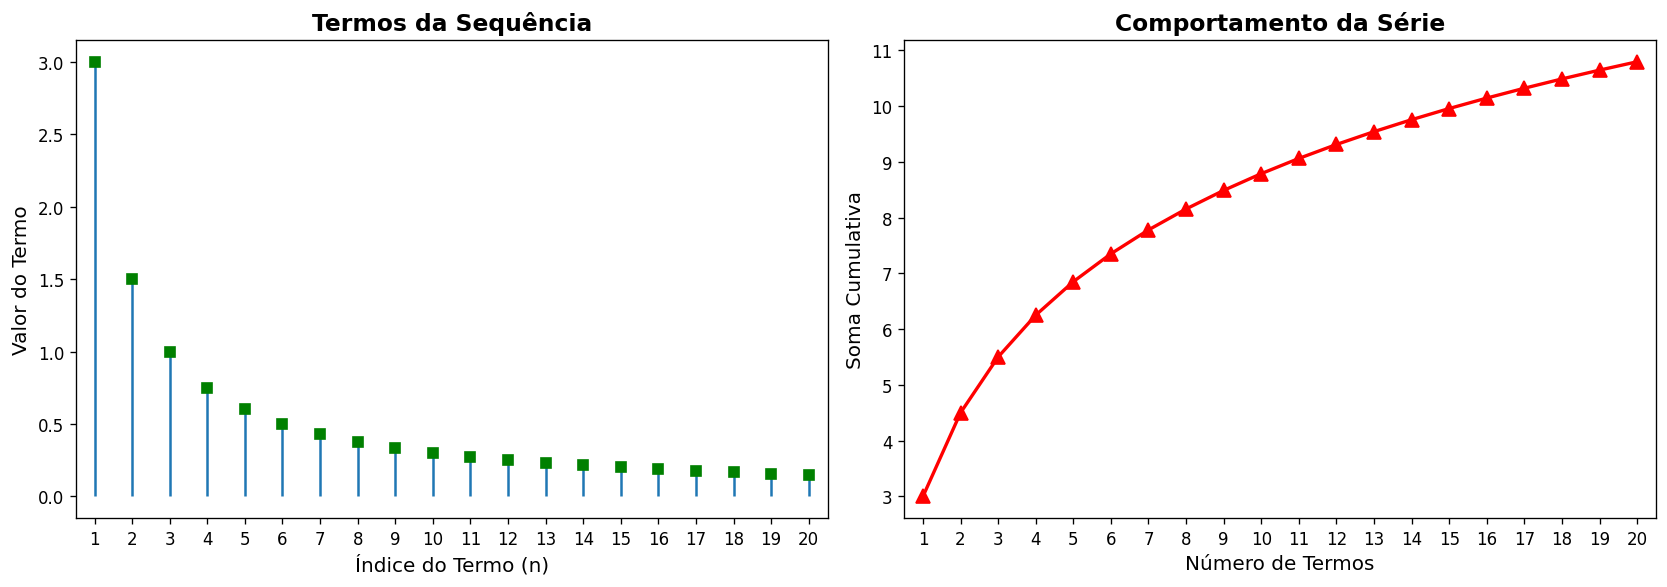

In [18]:
# 1. Consturindo a função para visualizar séries definidas pelo usuário

import numpy as np
import matplotlib.pyplot as plt
import math


def plotar_serie(termo_geral, n_termos, x_min=-10, x_max=10):
    """
    Plota uma série baseada no termo geral fornecido.

    Parâmetros:
    - termo_geral: função que define o termo geral da série (ex: lambda n: 1/n)
    - n_termos: número de termos a visualizar
    - x_min, x_max: limites do gráfico
    """
    # 1.1 Gerando os índices e os termos da série, e suas somas cumulativas
    n_indices = np.arange(1, n_termos + 1)
    termos = np.array([termo_geral(n) for n in n_indices])
    soma_cumulativa = np.cumsum(termos)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    # 1.2 Plotando os gráficos
    ## Gráfico 1: Termos da série
    ax1.stem(n_indices, termos, basefmt=' ', markerfmt='gs')
    ax1.set_xlabel('Índice do Termo (n)', fontsize=12)
    ax1.set_ylabel('Valor do Termo', fontsize=12)
    ax1.set_title('Termos da Sequência', fontsize=14, fontweight='bold')
    ax1.grid(False)

    ## Gráfico 2: Soma cumulativa
    ax2.plot(n_indices, soma_cumulativa, 'r^-', linewidth=2, markersize=8)
    ax2.set_xlabel('Número de Termos', fontsize=12)
    ax2.set_ylabel('Soma Cumulativa', fontsize=12)
    ax2.set_title('Comportamento da Série', fontsize=14, fontweight='bold')
    ax2.grid(False)

    ## Garantindo que os índices do eixo x sejam inteiros
    ax1.set_xticks(n_indices)
    ax2.set_xticks(n_indices)
    ## Ajustando os limites para deixar a escala mais limpa
    ax1.set_xlim(0.5, n_termos + 0.5)
    ax2.set_xlim(0.5, n_termos + 0.5)
    plt.tight_layout()
    plt.show()

    return termos, soma_cumulativa

# Exemplo de uso:
# plotar_serie(lambda n: 1/n**2, 20)

plotar_serie(lambda n:3/n, 20);

## Aula 3 - 20/08/2026 — Testes de Convergência

### Programa para determinar convergência ou divergência de uma série

In [19]:
import sympy as sp

def termo_geral():
    print("="*50)
    print(" ANÁLISE DE CONVERGÊNCIA DE SÉRIES NUMÉRICAS ")
    print("="*50)
    print(" Digite o termo geral a_n da série usando a sintaxe do Python ")
    print(" Exemplo: 1/n**2, 3/n, 1/(2*n), 1/(n*(n+1)), (-1)**n/n, 3**n/sp.factorial(n), etc.")
    print(" Observação: Use 'n' como variável independente.")
    print("="*50)

    n = sp.Symbol('n', integer=True, positive=True)
    entrada = input("a_n = ")

    try:
        an = sp.sympify(entrada, locals={'sp': sp, 'n': n})
    except Exception as e:
        print(f"Erro ao interpretar o termo geral: {e}")
        return None

    return an, n

def teste_divergencia(an, n):
    print("\n --- 1. Teste do termo geral (Divergência) ---")
    limite = sp.limit(an, n, sp.oo)
    print(f"Limite de a_n quando n -> oo: {limite}")
    if limite != 0:
        return "divergente."
    return "inconclusivo."

def teste_comparacao(an, n):
    print("\n --- 2. Teste da Comparação ---")
    p = int(input("Digite o valor de p: "))
    an_comparacao = 1/n**p
    limite_comparacao = sp.limit(an/an_comparacao, n, sp.oo)
    print(f"Limite de a_n / (1/n^{p}) quando n -> oo: {limite_comparacao}")

    if limite_comparacao > 0 and limite_comparacao < sp.oo:
        return "convergente." if p > 1 else "divergente."
    return "inconclusivo."

def teste_razao(an, n):
    print("\n --- 3. Teste da Razão ---")
    razao = sp.limit(an.subs(n, n+1)/an, n, sp.oo)
    print(f"Limite da razão a_(n+1)/a_n quando n -> oo: {razao}")
    if razao < 1:
        return "convergente."
    if razao > 1:
        return "divergente."
    return "inconclusivo."

def teste_raiz(an, n):
    print("\n --- 4. Teste da Raiz ---")
    raiz = sp.limit(sp.Abs(an)**(1/n), n, sp.oo)
    print(f"Limite da raiz n-ésima |a_n|^(1/n) quando n -> oo: {raiz}")
    try:
        if raiz < 1:
            return "convergente."
        if raiz > 1:
            return "divergente."
    except Exception:
        pass
    return "inconclusivo."

def teste_serie_alternada(an, n):
    print("\n--- 5. Teste da Série Alternada ---")

    bn = an.subs({(-1)**n: 1, (-1)**(n+1): 1, (-1)**(n-1): 1})
    bn = sp.simplify(sp.Abs(bn))

    if bn == sp.simplify(sp.Abs(an)):
        print("Aviso: A série inserida não parece ser alternada (não contém (-1)**n ou similar).")
        return "inconclusivo."

    print(f"Parte não alternante isolada b_n = {bn}")
    limite_bn = sp.limit(bn, n, sp.oo)
    print(f"1. Limite de b_n quando n -> oo: {limite_bn}")

    if limite_bn != 0:
        print("Como o limite não é zero, a série original diverge pelo Teste do Termo Geral.")
        return "divergente."

    x = sp.Symbol('x', real=True, positive=True)
    bx = bn.subs(n, x)
    derivada = sp.diff(bx, x)
    limite_derivada = sp.limit(derivada, x, sp.oo)
    print(f"2. Tendência da variação (derivada de b_n) quando n -> oo: {limite_derivada}")

    if limite_derivada < 0 or sp.limit(bn.subs(n, n+1)/bn, n, sp.oo) <= 1:
        print("A sequência b_n é decrescente.")
        return "convergente."

    print("Não foi possível confirmar se a sequência é estritamente decrescente.")
    return "inconclusivo."


def menu(an, n):
    print("\nEscolha o teste que deseja realizar:")
    print("1. Teste do termo geral (Divergência)")
    print("2. Teste da Comparação")
    print("3. Teste da Razão")
    print("4. Teste da Raiz")
    print("5. Teste da Série Alternada")
    escolha = input("Digite o número do teste desejado (ou 'sair' para encerrar): ")

    if escolha == '1':
        resultado = teste_divergencia(an, n)
    elif escolha == '2':
        resultado = teste_comparacao(an, n)
    elif escolha == '3':
        resultado = teste_razao(an, n)
    elif escolha == '4':
        resultado = teste_raiz(an, n)
    elif escolha == '5':
        resultado = teste_serie_alternada(an, n)
    elif escolha.lower() == 'sair':
        print("Encerrando o programa.")
        return
    else:
        print("Opção inválida. Tente novamente.")
        return menu(an, n)

    print(f"Resultado do teste escolhido: A série é {resultado}")

if __name__ == "__main__":
    entrada = termo_geral()
    if entrada is not None:
        an, n = entrada
        menu(an, n)


 ANÁLISE DE CONVERGÊNCIA DE SÉRIES NUMÉRICAS 
 Digite o termo geral a_n da série usando a sintaxe do Python 
 Exemplo: 1/n**2, 3/n, 1/(2*n), 1/(n*(n+1)), (-1)**n/n, 3**n/sp.factorial(n), etc.
 Observação: Use 'n' como variável independente.
Erro ao interpretar o termo geral: Sympify of expression 'could not parse ''' failed, because of exception being raised:
SyntaxError: invalid syntax (<string>, line 0)


## Aula 5 - 27/08/2026 — Séries de Maclaurin e de Taylor

### Exemplo da série de Taylor (e, neste caso, de Maclaurin) da função seno

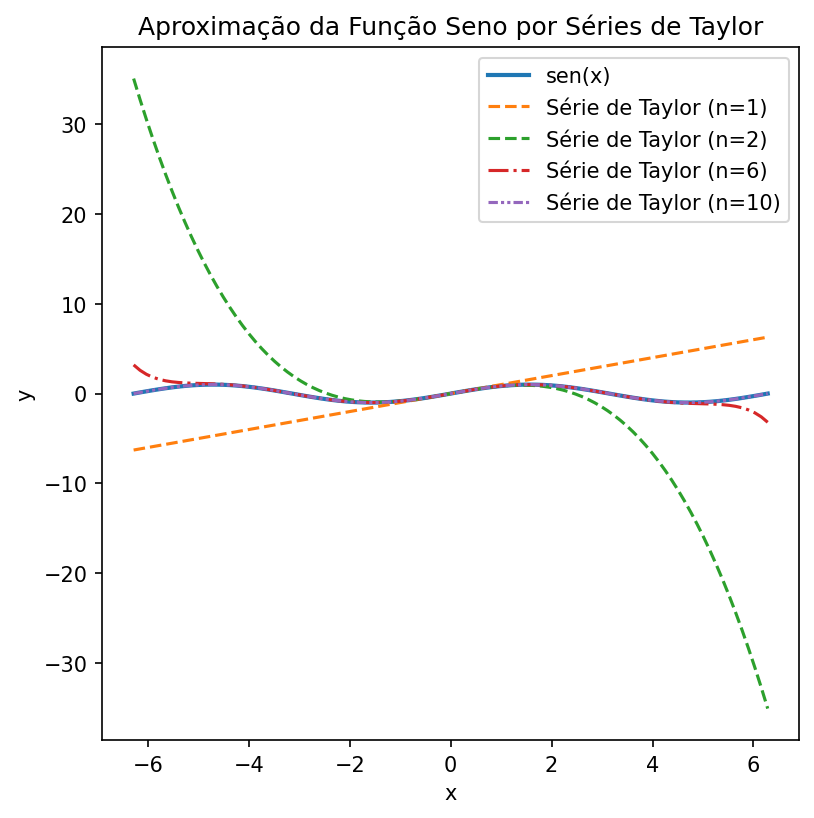

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Definindo a função seno
def seno(x):
    return np.sin(x)

# 2. Definindo a série de Taylor do seno em torno de x=0 ( uma série de Maclaurin)
def serie_taylor_seno(x, n):
    soma = 0
    for i in range(n):
        termo = ((-1)**i * x**(2*i + 1)) / math.factorial(2*i + 1)
        soma += termo
    return soma

def serie_taylor(x, n):
    funcao = 0
    

# 3. Valores de x para os quais queremos calcular a série
x_vals = np.linspace(-2*np.pi, 2*np.pi, 100)

# 4. Plotando a função original e a série de Taylor
plt.figure(figsize=(6, 6), dpi=150)
plt.plot(x_vals, seno(x_vals), label='sen(x)', linewidth=2)
plt.plot(x_vals, serie_taylor_seno(x_vals, 1), label='Série de Taylor (n=1)', linestyle='--')
plt.plot(x_vals, serie_taylor_seno(x_vals, 2), label='Série de Taylor (n=2)', linestyle='--')
plt.plot(x_vals, serie_taylor_seno(x_vals, 6), label='Série de Taylor (n=6)', linestyle='-.')
plt.plot(x_vals, serie_taylor_seno(x_vals, 10), label='Série de Taylor (n=10)', linestyle=(0, (3, 1, 1, 1, 1, 1)))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Aproximação da Função Seno por Séries de Taylor')
plt.legend()
plt.grid(False)
plt.show()